In [2]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt

events = pd.read_csv("events.dat", sep=" ")
events["chirp_mass"] = (events["mass_1"] * events["mass_2"])**0.6 / (events["mass_1"] + events["mass_2"])**0.2
events["mass_ratio"] = events["mass_2"] / events["mass_1"]

(array([ 2.,  1.,  0.,  3.,  4.,  9.,  5., 23., 23., 17.]),
 array([0.72582053, 0.75317668, 0.78053282, 0.80788897, 0.83524511,
        0.86260126, 0.8899574 , 0.91731355, 0.94466969, 0.97202584,
        0.99938198]),
 <BarContainer object of 10 artists>)

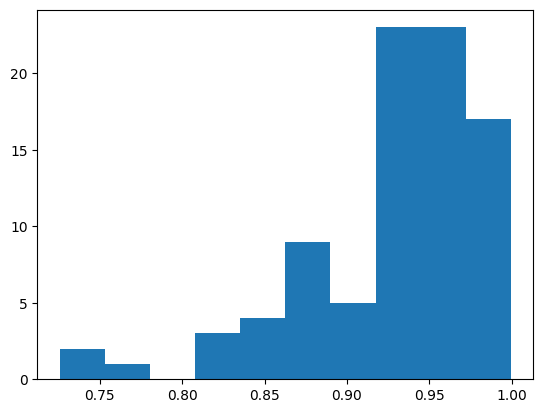

In [3]:
plt.hist(events["mass_ratio"])

In [17]:
def quantile_list(key):
    quantiles = np.zeros(86)
    for j in range(86):
    
        posterior = np.load(f"gw_posteriors/source_{j}/posterior.npz")
    
        quantiles[j] = np.sum(posterior[key]<=events.loc[j, key]) / posterior[key].shape[0]

    return quantiles

quantiles = quantile_list("mass_1_source")
quantiles_detector = quantile_list("mass_1")
quantiles_chirp = quantile_list('chirp_mass')
quantiles_mass_ratio = quantile_list('mass_ratio')

Text(0.5, 0, 'chirp mass quantiles')

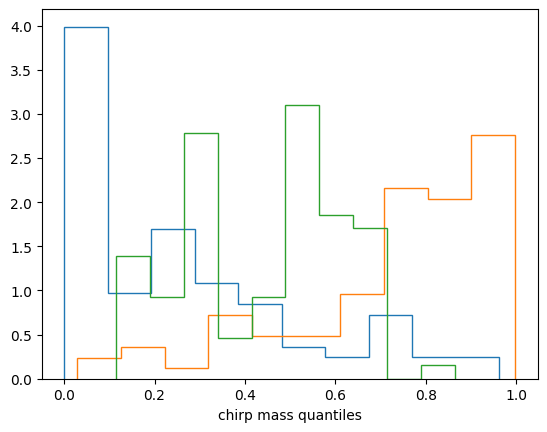

In [6]:

plt.hist(quantiles_chirp, histtype="step", density=True)
plt.hist(quantiles_mass_ratio, histtype="step", density=True)
plt.hist(quantile_list("chi_1"), histtype="step", density=True)
plt.xlabel("chirp mass quantiles")

In [18]:
quantiles_mass_ratio.argsort()


array([36, 75, 33, 28, 47, 76, 83, 79, 57, 82, 27, 58, 31, 73, 67, 38, 59,
       21, 43, 18, 13,  6, 26, 51,  7, 10, 11, 24, 15, 29, 50,  5, 62,  0,
       74, 22, 42, 20, 61, 40, 68, 19, 55,  9,  1, 14, 69, 35, 84, 16, 45,
       53,  8, 12, 25, 70, 81, 56,  3, 65, 71, 66, 44, 85, 39, 52, 34, 60,
        4, 48, 41,  2, 63, 32, 30, 46, 77, 23, 78, 49, 17, 72, 37, 80, 64,
       54])

In [19]:
np.sort(quantiles_mass_ratio)

array([0.02835661, 0.10846855, 0.17077142, 0.18665504, 0.21297631,
       0.2756827 , 0.32875803, 0.33802198, 0.35057048, 0.36735126,
       0.38028813, 0.40869219, 0.42053415, 0.44772546, 0.5031185 ,
       0.50489663, 0.51832335, 0.52053591, 0.54985033, 0.60819146,
       0.61050505, 0.61276392, 0.62272818, 0.63093682, 0.63779713,
       0.64296407, 0.64979995, 0.67668002, 0.70742259, 0.71491045,
       0.71696468, 0.72290091, 0.72502884, 0.7329913 , 0.73511604,
       0.73868263, 0.74080772, 0.74393231, 0.74554217, 0.76006819,
       0.76841869, 0.76904532, 0.77042802, 0.77874348, 0.78192352,
       0.80284153, 0.80522907, 0.82114789, 0.83437735, 0.83564593,
       0.83611497, 0.84777143, 0.85653683, 0.8695158 , 0.87424749,
       0.87429644, 0.87735405, 0.88018018, 0.88188799, 0.88221106,
       0.88301095, 0.89482136, 0.89492431, 0.90240334, 0.91942938,
       0.9200468 , 0.92559242, 0.92625746, 0.93340517, 0.93566022,
       0.93835452, 0.94650952, 0.95088242, 0.95093063, 0.95142

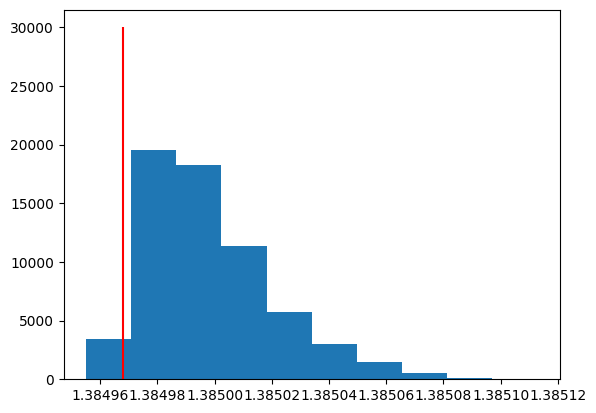

In [7]:
posterior = np.load("./gw_posteriors/source_42/posterior.npz")
plt.hist(posterior["chirp_mass"], density=True)
plt.vlines([events.loc[42, "chirp_mass"]], 0, 30_000, color="red")

In [19]:
from jesterTOV.inference.transforms import MultimessengerJesterTransform
from jesterTOV.utils import solar_mass_in_meter

from nmma.core.conversion import BNSEjectaFitting

/home/koehn1/miniconda3/envs/nmma_x_fiesta/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
mass_1 = events.loc[22, "mass_1_source"]
mass_2 = events.loc[22, "mass_2_source"]
radius_1 = events.loc[22, "radius_1"]
radius_2 = events.loc[22, "radius_2"]
compactness_1 = mass_1 / radius_1 * solar_mass_in_meter * 1e-3
compactness_2 = mass_2 / radius_2 * solar_mass_in_meter * 1e-3

log10_mej_dyn = np.log10(MultimessengerJesterTransform.dynamic_mass_fitting(mass_1, mass_2, compactness_1, compactness_2))

In [23]:
print(log10_mej_dyn, events.loc[22, "log10_mej_dyn"])

-2.235712866528109 -2.235648111224239


In [31]:
import jax

jax.random.uniform(jax.random.key(57191), shape=(10,), minval=1.32, maxval=1.2)

Array([1.32, 1.32, 1.32, 1.32, 1.32, 1.32, 1.32, 1.32, 1.32, 1.32],      dtype=float64)

In [22]:
events["mass_ratio"].min()

np.float64(0.7258205335293277)